# Notebook 03: Diebold-Li State-Space Estimation

We fit the Diebold-Li model to the ECB AAA yield curve data using a
Kalman-filter marginal likelihood embedded in PyMC. NUTS provides full
posterior uncertainty on all parameters.

**Input:** `../data/ecb_data.pkl` (from notebook 02)

**Estimated parameters:** $\boldsymbol{\mu}$, $\text{diag}(\boldsymbol{\Phi})$,
$\mathbf{q}_{\text{stds}}$, $\sigma_{\text{obs}}$

**Output:** filtered factors $(\hat{L}_t, \hat{S}_t, \hat{C}_t)$ passed to notebook 04.
We compare against the preliminary OLS factors from notebook 02 (no "true" factors
since we are now working with real data).

In [1]:
import sys
sys.path.insert(0, "../src")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pymc as pm
import arviz as az

from simulate import MATURITIES, SEGMENTS
from diebold_li import build_dl_model, extract_factors_numpy

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## 1. Load ECB Data

In [2]:
with open("../data/ecb_data.pkl", "rb") as f:
    ecb_data = pickle.load(f)

yields      = ecb_data["yields"]       # (T, J) monthly ECB yield curve
factors_ols = ecb_data["factors_ols"]  # (T, 3) OLS Nelson-Siegel factors
dates       = yields.index

y_obs = yields.values.astype(np.float64)   # (T, J)
T, J  = y_obs.shape

print(f"T={T} months, J={J} maturities")
print(f"Period: {dates[0].date()} to {dates[-1].date()}")
print(f"Yield range: [{y_obs.min():.2f}, {y_obs.max():.2f}]%")

T=132 months, J=8 maturities
Period: 2014-01-01 to 2024-12-01
Yield range: [-0.90, 3.85]%


## 2. Prior Predictive Check

Before sampling the posterior, we verify that the prior predictive distribution
covers the observed yield range without being absurdly wide.

Key check: does the prior on $\mu$ span the actual factor range seen in the ECB data
(Level ranging from ~-1% to ~4%)?

C:\Users\thoma\AppData\Local\Temp\ipykernel_63688\1545413577.py:4: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior_idata = pm.sample_prior_predictive(samples=200, random_seed=0)


Sampling: [mu, phi_diag, q_stds, sigma_obs]


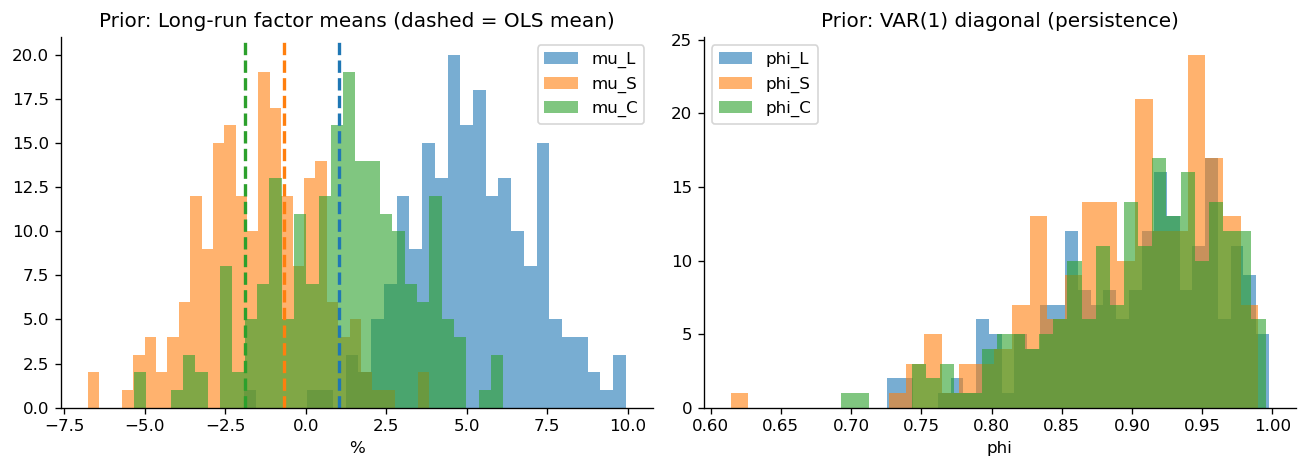

In [3]:
model = build_dl_model(y_obs)

with model:
    prior_idata = pm.sample_prior_predictive(samples=200, random_seed=0)

# Extract prior samples of mu and phi to check plausibility
mu_prior  = prior_idata.prior["mu"].values.reshape(-1, 3)
phi_prior = prior_idata.prior["phi_diag"].values.reshape(-1, 3)

# OLS factor means for reference
ols_means = factors_ols.mean().values

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
for i, (name, c) in enumerate(zip(["mu_L", "mu_S", "mu_C"], ["#1f77b4", "#ff7f0e", "#2ca02c"])):
    ax.hist(mu_prior[:, i], bins=30, alpha=0.6, color=c, label=name)
    ax.axvline(ols_means[i], color=c, lw=2, ls="--")
ax.set_title("Prior: Long-run factor means (dashed = OLS mean)")
ax.set_xlabel("%")
ax.legend()

ax = axes[1]
for i, (name, c) in enumerate(zip(["phi_L", "phi_S", "phi_C"], ["#1f77b4", "#ff7f0e", "#2ca02c"])):
    ax.hist(phi_prior[:, i], bins=30, alpha=0.6, color=c, label=name)
ax.set_title("Prior: VAR(1) diagonal (persistence)")
ax.set_xlabel("phi")
ax.legend()

fig.tight_layout()
plt.show()

## 3. NUTS Sampling

The Kalman filter marginal likelihood is computed via `pytensor.scan` inside the model.
NUTS differentiates through the T filter steps at each gradient evaluation.

We use `nuts_sampler="numpyro"` for faster JAX-compiled sampling.

In [4]:
with model:
    idata_dl = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        random_seed=123,
        progressbar=True,
        nuts_sampler="numpyro",
    )

print(az.summary(idata_dl, var_names=["mu", "phi_diag", "q_stds", "sigma_obs"]))

C:\Users\thoma\.conda\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics


              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu[0]        2.183  1.065   0.463    4.304      0.037    0.031     943.0   
mu[1]       -0.487  0.628  -1.615    0.741      0.023    0.023     856.0   
mu[2]       -1.940  0.611  -3.081   -0.787      0.018    0.020    1315.0   
phi_diag[0]  0.984  0.010   0.966    0.999      0.000    0.000     777.0   
phi_diag[1]  0.972  0.013   0.950    0.997      0.000    0.000     897.0   
phi_diag[2]  0.954  0.020   0.919    0.992      0.001    0.000    1227.0   
q_stds[0]    0.159  0.012   0.136    0.182      0.000    0.000    1782.0   
q_stds[1]    0.187  0.014   0.160    0.214      0.000    0.000    2021.0   
q_stds[2]    0.332  0.035   0.269    0.398      0.001    0.001    1950.0   
sigma_obs    0.076  0.002   0.072    0.080      0.000    0.000    2094.0   

             ess_tail  r_hat  
mu[0]           886.0    1.0  
mu[1]           800.0    1.0  
mu[2]           861.0    1.0  
phi_diag[0]     988.0    1.0  
phi_diag

## 4. Posterior Diagnostics

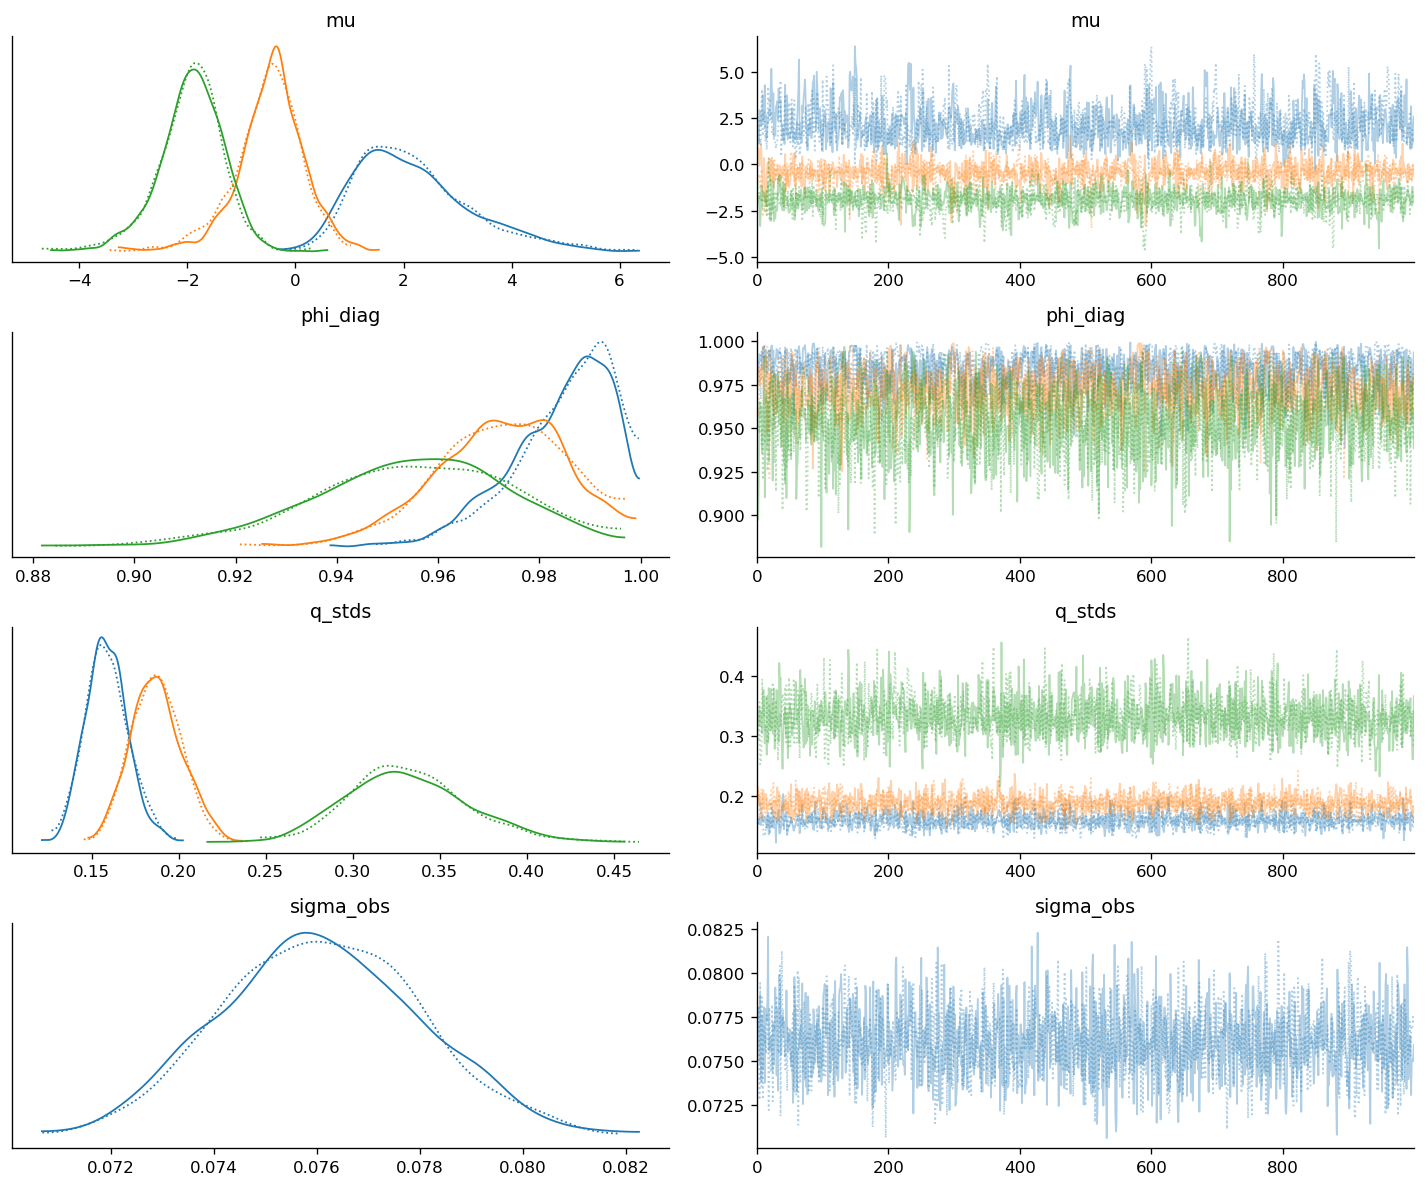

In [5]:
az.plot_trace(
    idata_dl,
    var_names=["mu", "phi_diag", "q_stds", "sigma_obs"],
    figsize=(12, 10),
    compact=True,
)
plt.tight_layout()
plt.show()

## 5. Parameter Summary

With real data we cannot compare to a "true" value, but we can check that
estimated long-run means and persistence are economically reasonable.

In [6]:
post = idata_dl.posterior
mu_post   = post["mu"].mean(("chain", "draw")).values
phi_post  = post["phi_diag"].mean(("chain", "draw")).values
qstd_post = post["q_stds"].mean(("chain", "draw")).values
sig_post  = float(post["sigma_obs"].mean(("chain", "draw")).values)

# 94% HDI
mu_hdi   = az.hdi(idata_dl, var_names=["mu"],       hdi_prob=0.94)["mu"].values
phi_hdi  = az.hdi(idata_dl, var_names=["phi_diag"], hdi_prob=0.94)["phi_diag"].values

print("Posterior parameter summary (94% HDI):")
print(f"{'Parameter':<20} {'Mean':>8} {'HDI 3%':>8} {'HDI 97%':>8}")
print("-" * 48)
for i, name in enumerate(["mu_L", "mu_S", "mu_C"]):
    print(f"{name:<20} {mu_post[i]:>8.3f} {mu_hdi[i, 0]:>8.3f} {mu_hdi[i, 1]:>8.3f}")
for i, name in enumerate(["phi_L", "phi_S", "phi_C"]):
    print(f"{name:<20} {phi_post[i]:>8.3f} {phi_hdi[i, 0]:>8.3f} {phi_hdi[i, 1]:>8.3f}")
print(f"{'sigma_obs':<20} {sig_post:>8.3f}")

print(f"\nOLS factor means for comparison: L={ols_means[0]:.3f}, S={ols_means[1]:.3f}, C={ols_means[2]:.3f}")

Posterior parameter summary (94% HDI):
Parameter                Mean   HDI 3%  HDI 97%
------------------------------------------------
mu_L                    2.183    0.463    4.304
mu_S                   -0.487   -1.615    0.741
mu_C                   -1.940   -3.081   -0.787
phi_L                   0.984    0.966    0.999
phi_S                   0.972    0.950    0.997
phi_C                   0.954    0.919    0.992
sigma_obs               0.076

OLS factor means for comparison: L=1.038, S=-0.666, C=-1.902


## 6. Factor Extraction: DL Filtered vs OLS

We run a forward Kalman pass with posterior mean parameters to extract
filtered factors $\hat{\mathbf{f}}_{t|t}$.

The DL filtered factors should be smoother than the OLS estimates
(Kalman filter borrows strength from the state dynamics) and better
suited as inputs to the repricing model.

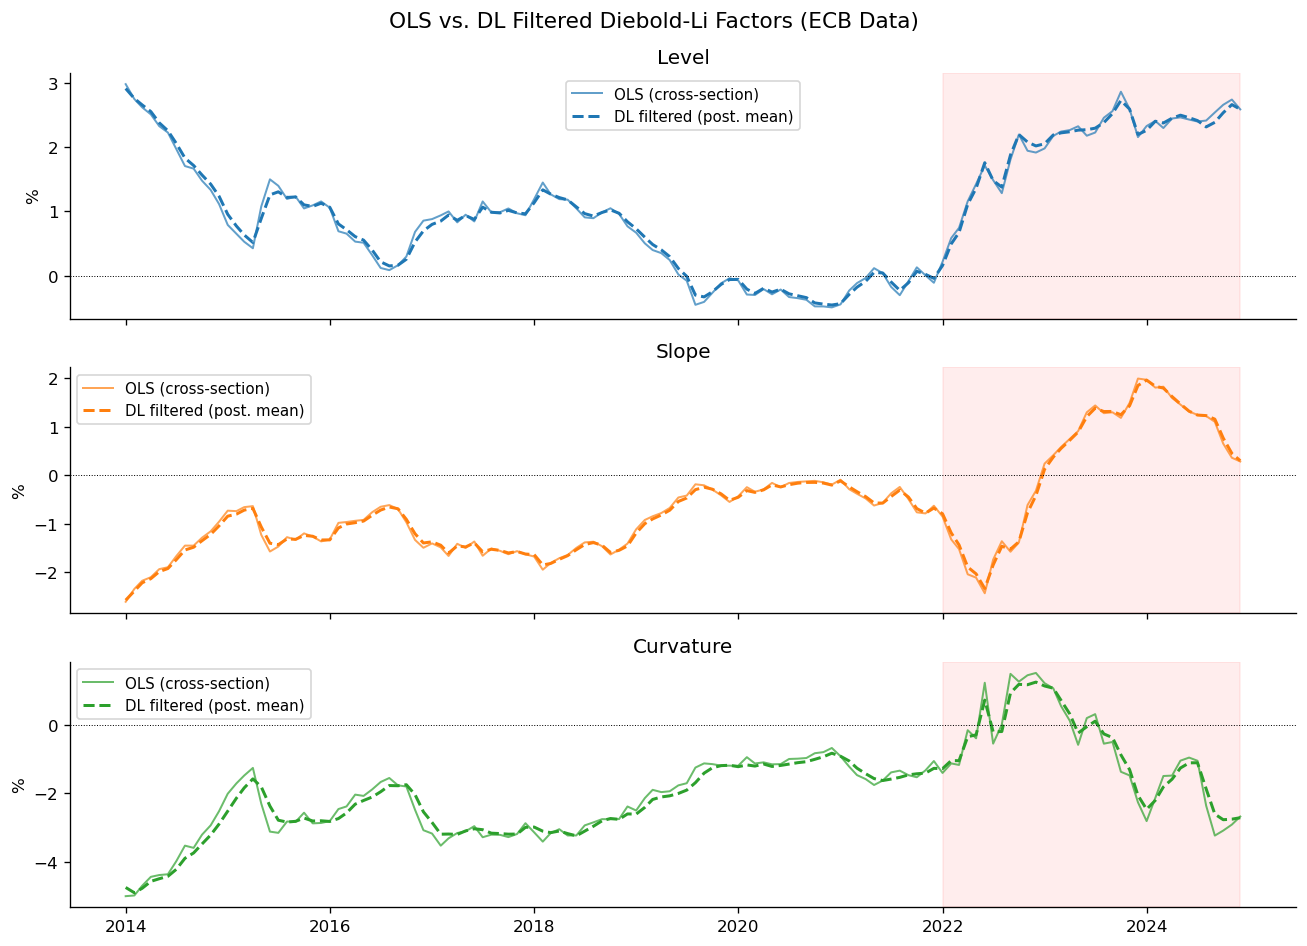

In [7]:
factors_filtered_arr = extract_factors_numpy(idata_dl, y_obs)  # (T, 3)

factors_filtered = pd.DataFrame(
    factors_filtered_arr,
    index=dates,
    columns=["Level", "Slope", "Curvature"],
)

colors       = ["#1f77b4", "#ff7f0e", "#2ca02c"]
factor_names = ["Level", "Slope", "Curvature"]

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for i, (ax, name, c) in enumerate(zip(axes, factor_names, colors)):
    ax.plot(dates, factors_ols[name], color=c, lw=1.2, alpha=0.7, label="OLS (cross-section)")
    ax.plot(dates, factors_filtered[name], color=c, lw=1.8, ls="--", label="DL filtered (post. mean)")
    ax.axhline(0, color="black", lw=0.6, ls=":")
    ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.07, color="red")
    ax.set_ylabel("%")
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("OLS vs. DL Filtered Diebold-Li Factors (ECB Data)", fontsize=13)
fig.tight_layout()
plt.show()

## 7. Yield Curve Fit

We compute implied yields from the filtered factors and measure RMSE by maturity.
The NS model should fit particularly well in the middle maturities.

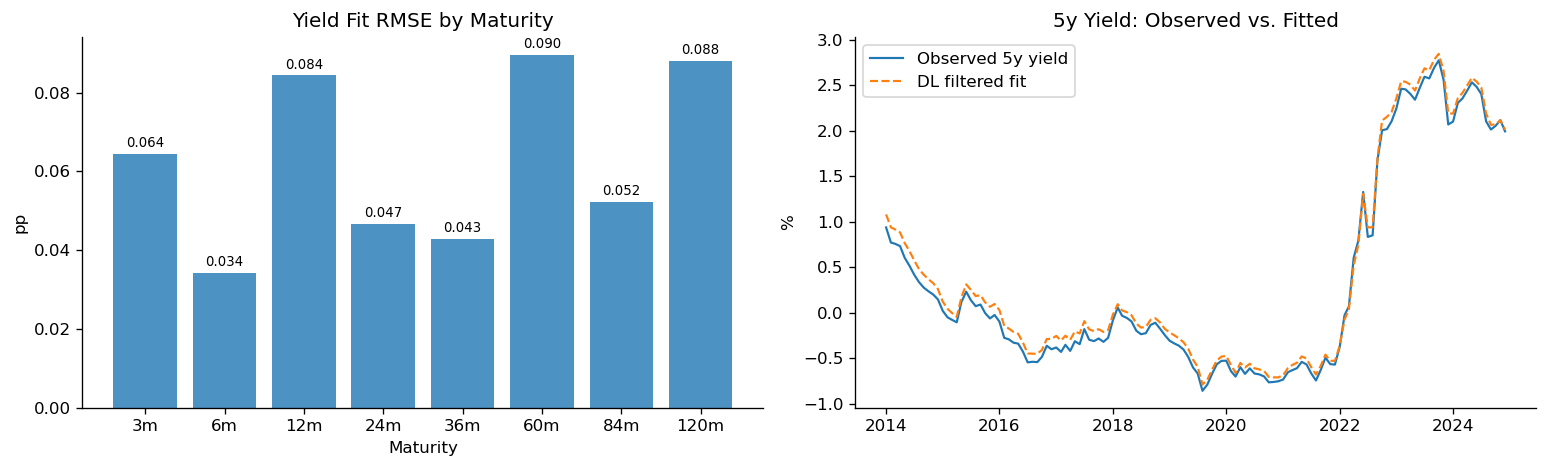

Overall RMSE: 0.0661%


In [8]:
from diebold_li import LAMBDA_MAT

y_fitted  = factors_filtered_arr @ LAMBDA_MAT.T   # (T, J)
residuals = y_obs - y_fitted
mat_labels = yields.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# RMSE by maturity
rmse = np.sqrt(np.mean(residuals ** 2, axis=0))
ax = axes[0]
ax.bar(mat_labels, rmse, color="#1f77b4", alpha=0.8)
ax.set_title("Yield Fit RMSE by Maturity")
ax.set_ylabel("pp")
ax.set_xlabel("Maturity")
for i, (label, val) in enumerate(zip(mat_labels, rmse)):
    ax.text(i, val + 0.001, f"{val:.3f}", ha="center", va="bottom", fontsize=8)

# Observed vs fitted for 5y maturity
idx_5y = mat_labels.index("60m")
ax = axes[1]
ax.plot(dates, y_obs[:, idx_5y],     lw=1.3, label="Observed 5y yield")
ax.plot(dates, y_fitted[:, idx_5y],  lw=1.3, ls="--", label="DL filtered fit")
ax.set_title("5y Yield: Observed vs. Fitted")
ax.set_ylabel("%")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()

print(f"Overall RMSE: {np.sqrt(np.mean(residuals**2)):.4f}%")

## 8. Save Results

Save to `../data/dl_results.pkl`.
Keys: `idata`, `factors_filtered`.

In [9]:
results_dl = {
    "idata":            idata_dl,
    "factors_filtered": factors_filtered,
}
with open("../data/dl_results.pkl", "wb") as f:
    pickle.dump(results_dl, f)
print("Saved to ../data/dl_results.pkl")
print(f"factors_filtered shape: {factors_filtered.shape}")

Saved to ../data/dl_results.pkl
factors_filtered shape: (132, 3)
